In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import nfl_data_py as nfl

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

YEARS = list(range(2000, 2026))

In [2]:
draft = nfl.import_draft_picks(YEARS)

draft.head()

,season,round,pick,team,gsis_id,pfr_player_id,cfb_player_id,pfr_player_name,hof,position,...,pass_ints,rush_atts,rush_yards,rush_tds,receptions,rec_yards,rec_tds,def_solo_tackles,def_ints,def_sacks
6026,2000,1,1,CLE,00-0018954,BrowCo22,courtney-brown-1,Courtney Brown,False,DE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,156.0,NaN,19.0
6027,2000,1,2,WAS,00-0019692,ArriLa00,lavar-arrington-1,LaVar Arrington,False,LB,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,338.0,3.0,23.5
6028,2000,1,3,WAS,00-0019640,SamuCh00,chris-samuels-2,Chris Samuels,False,T,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
6029,2000,1,4,CIN,00-0019455,WarrPe00,peter-warrick-1,Peter Warrick,False,WR,...,0.0,53.0,360.0,2.0,275.0,2991.0,18.0,3.0,NaN,NaN
6030,2000,1,5,BAL,00-0019693,LewiJa00,jamal-lewis-2,Jamal Lewis,False,RB,...,0.0,2542.0,10607.0,58.0,221.0,1879.0,4.0,NaN,NaN,NaN


In [3]:
draft.columns

Index(['season', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id',
       'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts',
       'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards',
       'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles',
       'def_ints', 'def_sacks'],
      dtype='str')

In [4]:
draft.to_csv(RAW_DIR / "draft_2000_2026.csv", index=False)

In [5]:
combine = nfl.import_combine_data()
combine.head()

,season,draft_year,draft_team,draft_round,draft_ovr,pfr_id,cfb_id,player_name,pos,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
0,2000,2000.0,New York Jets,1.0,13.0,AbraJo00,NaN,John Abraham,OLB,South Carolina,6-4,252.0,4.55,NaN,NaN,NaN,NaN,NaN
1,2000,2000.0,Seattle Seahawks,1.0,19.0,AlexSh00,shaun-alexander-1,Shaun Alexander,RB,Alabama,6-0,218.0,4.58,NaN,NaN,NaN,NaN,NaN
2,2000,2000.0,Kansas City Chiefs,6.0,188.0,AlfoDa20,NaN,Darnell Alford,OT,Boston Col.,6-4,334.0,5.56,23.0,25.0,94.0,8.48,4.98
3,2000,NaN,NaN,NaN,NaN,NaN,NaN,Kyle Allamon,TE,Texas Tech,6-2,253.0,4.97,NaN,29.0,104.0,7.29,4.49
4,2000,2000.0,Carolina Panthers,1.0,23.0,AndeRa21,NaN,Rashard Anderson,CB,Jackson State,6-2,206.0,4.55,NaN,34.0,123.0,7.18,4.15


In [6]:
combine.columns

Index(['season', 'draft_year', 'draft_team', 'draft_round', 'draft_ovr',
       'pfr_id', 'cfb_id', 'player_name', 'pos', 'school', 'ht', 'wt', 'forty',
       'bench', 'vertical', 'broad_jump', 'cone', 'shuttle'],
      dtype='str')

In [7]:
combine.to_csv(RAW_DIR / "combine_2000_2026.csv", index=False)

In [8]:
print("Draft shape:", draft.shape)
print("Combine shape:", combine.shape)


Draft shape: (6644, 36)
Combine shape: (8968, 18)


In [9]:
draft.duplicated(subset=["season", "pick"]).sum()

np.int64(0)

In [13]:
draft[draft.duplicated(subset=["season", "pick"], keep=False)]

,season,round,pick,team,gsis_id,pfr_player_id,cfb_player_id,pfr_player_name,hof,position,...,pass_ints,rush_atts,rush_yards,rush_tds,receptions,rec_yards,rec_tds,def_solo_tackles,def_ints,def_sacks


In [10]:
combine.duplicated(subset=["season", "player_name"]).sum()

np.int64(10)

In [11]:
combine[combine.duplicated(subset=["season", "player_name"], keep=False)]

,season,draft_year,draft_team,draft_round,draft_ovr,pfr_id,cfb_id,player_name,pos,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
116,2000,2000.0,Tennessee Titans,7.0,213.0,GreeMi00,NaN,Mike Green,S,NW State (LA),6-0,189.0,4.53,NaN,38.5,118.0,NaN,4.20
117,2000,2000.0,Tennessee Titans,7.0,213.0,GreeMi00,mike-green-4,Mike Green,FB,Houston,6-0,253.0,4.78,25.0,28.5,108.0,7.08,4.34
699,2002,NaN,NaN,NaN,NaN,NaN,NaN,Mike Collins,OT,Wake Forest,6-5,300.0,5.53,32.0,25.5,104.0,8.62,4.98
700,2002,NaN,NaN,NaN,NaN,NaN,NaN,Mike Collins,DT,Ohio State,6-3,298.0,5.03,31.0,31.5,105.0,7.52,4.46
849,2002,NaN,NaN,NaN,NaN,MoorBr00,NaN,Brandon Moore,OLB,Oklahoma,6-1,239.0,4.61,23.0,36.5,113.0,NaN,NaN
850,2002,NaN,NaN,NaN,NaN,MoorBr20,NaN,Brandon Moore,DT,Illinois,6-3,293.0,5.26,32.0,25.5,96.0,7.84,4.64
991,2003,2003.0,Tennessee Titans,3.0,93.0,BrowCh03,chris-brown-1,Chris Brown,RB,Colorado,6-3,220.0,4.46,NaN,NaN,NaN,NaN,NaN
992,2003,NaN,NaN,NaN,NaN,BrowCh25,chris-brown-6,Chris Brown,S,Ala-Birmingham,6-0,195.0,4.59,15.0,35.5,126.0,7.05,4.13
1783,2005,2005.0,Kansas City Chiefs,1.0,15.0,JohnDe25,derrick-johnson-3,Derrick Johnson,CB,Texas,5-11,197.0,4.43,18.0,NaN,NaN,7.15,4.10
1784,2005,2005.0,Kansas City Chiefs,1.0,15.0,JohnDe25,derrick-johnson-3,Derrick Johnson,OLB,Texas,6-3,242.0,4.52,NaN,37.5,120.0,7.20,3.87


In [15]:
combine = combine.drop_duplicates(subset=["season", "player_name"])

In [16]:
draft.isna().mean().sort_values(ascending=False)

car_av              1.000000
def_ints            0.789133
def_sacks           0.712372
def_solo_tackles    0.363335
cfb_player_id       0.158790
dr_av               0.149458
pass_ints           0.088200
rec_tds             0.088049
rec_yards           0.088049
receptions          0.088049
rush_tds            0.088049
to                  0.088049
games               0.088049
pass_completions    0.088049
pass_attempts       0.088049
w_av                0.088049
rush_yards          0.088049
pass_yards          0.088049
pass_tds            0.088049
rush_atts           0.088049
gsis_id             0.042896
age                 0.039735
pfr_player_id       0.038531
side                0.000301
team                0.000000
pick                0.000000
round               0.000000
season              0.000000
probowls            0.000000
seasons_started     0.000000
college             0.000000
allpro              0.000000
pfr_player_name     0.000000
hof                 0.000000
position      

In [17]:
combine.isna().mean().sort_values(ascending=False)

cone           0.434584
shuttle        0.417392
bench          0.400201
draft_year     0.380665
draft_ovr      0.380665
draft_team     0.380665
draft_round    0.380665
broad_jump     0.255414
vertical       0.243135
pfr_id         0.170797
cfb_id         0.169681
forty          0.103706
ht             0.003237
wt             0.002679
season         0.000000
school         0.000000
player_name    0.000000
pos            0.000000
dtype: float64

In [57]:
merged = draft.merge(
    combine,
    left_on=["season","pick"],
    right_on=["draft_year","draft_ovr"],
    how="left"
)

merged.head()

,season_x,round,pick,team,gsis_id,pfr_player_id,cfb_player_id,pfr_player_name,hof,position,...,pos,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
0,2000,1,1,CLE,00-0018954,BrowCo22,courtney-brown-1,Courtney Brown,False,DE,...,DE,Penn State,6-5,269.0,4.78,NaN,NaN,NaN,NaN,NaN
1,2000,1,2,WAS,00-0019692,ArriLa00,lavar-arrington-1,LaVar Arrington,False,LB,...,OLB,Penn State,6-3,250.0,4.53,NaN,NaN,NaN,NaN,NaN
2,2000,1,3,WAS,00-0019640,SamuCh00,chris-samuels-2,Chris Samuels,False,T,...,OT,Alabama,6-5,325.0,5.08,NaN,NaN,NaN,NaN,NaN
3,2000,1,4,CIN,00-0019455,WarrPe00,peter-warrick-1,Peter Warrick,False,WR,...,WR,Florida State,5-11,194.0,4.58,NaN,NaN,NaN,NaN,NaN
4,2000,1,5,BAL,00-0019693,LewiJa00,jamal-lewis-2,Jamal Lewis,False,RB,...,RB,Tennessee,6-0,240.0,4.58,23.0,NaN,NaN,NaN,NaN


In [58]:
merged.columns

Index(['season_x', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id',
       'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts',
       'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards',
       'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles',
       'def_ints', 'def_sacks', 'season_y', 'draft_year', 'draft_team',
       'draft_round', 'draft_ovr', 'pfr_id', 'cfb_id', 'player_name', 'pos',
       'school', 'ht', 'wt', 'forty', 'bench', 'vertical', 'broad_jump',
       'cone', 'shuttle'],
      dtype='str')

In [59]:
merged = merged.drop(columns=[
    "draft_year",
    "draft_ovr",
    "draft_team",
    "draft_round"
])

In [60]:
merged.columns

Index(['season_x', 'round', 'pick', 'team', 'gsis_id', 'pfr_player_id',
       'cfb_player_id', 'pfr_player_name', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'w_av', 'car_av', 'dr_av', 'games', 'pass_completions', 'pass_attempts',
       'pass_yards', 'pass_tds', 'pass_ints', 'rush_atts', 'rush_yards',
       'rush_tds', 'receptions', 'rec_yards', 'rec_tds', 'def_solo_tackles',
       'def_ints', 'def_sacks', 'season_y', 'pfr_id', 'cfb_id', 'player_name',
       'pos', 'school', 'ht', 'wt', 'forty', 'bench', 'vertical', 'broad_jump',
       'cone', 'shuttle'],
      dtype='str')

In [61]:
merged.shape

(6651, 50)

In [62]:
merged["forty"].notna().mean()

np.float64(0.7639452713877612)

In [63]:
merged.duplicated(["season_x","pick"]).sum()

np.int64(7)

In [64]:
# fix season columns
merged = merged.rename(columns={"season_x": "season"})
merged = merged.drop(columns=["season_y"])

# drop identifiers
merged = merged.drop(columns=[
    "gsis_id",
    "pfr_player_id",
    "cfb_player_id",
    "pfr_id",
    "cfb_id",
    "pfr_player_name"
])

# drop post-draft stats (data leakage)
merged = merged.drop(columns=[
    "games",
    "pass_completions",
    "pass_attempts",
    "pass_yards",
    "pass_tds",
    "pass_ints",
    "rush_atts",
    "rush_yards",
    "rush_tds",
    "receptions",
    "rec_yards",
    "rec_tds",
    "def_solo_tackles",
    "def_ints",
    "def_sacks",
    "w_av",
    "car_av"
])

In [65]:
merged.shape

(6651, 26)

In [66]:
merged.columns

Index(['season', 'round', 'pick', 'team', 'hof', 'position', 'category',
       'side', 'college', 'age', 'to', 'allpro', 'probowls', 'seasons_started',
       'dr_av', 'player_name', 'pos', 'school', 'ht', 'wt', 'forty', 'bench',
       'vertical', 'broad_jump', 'cone', 'shuttle'],
      dtype='str')

In [67]:
merged.duplicated(["season","pick"]).sum()

np.int64(7)

In [68]:
dups = merged[merged.duplicated(["season","pick"], keep=False)]
dups.sort_values(["season","pick"])

,season,round,pick,team,hof,position,category,side,college,age,...,pos,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
853,2003,3,93,TEN,False,RB,RB,O,Colorado,22.0,...,OT,Georgia Tech,6-5,329.0,5.33,30.0,NaN,NaN,NaN,NaN
854,2003,3,93,TEN,False,RB,RB,O,Colorado,22.0,...,RB,Colorado,6-3,220.0,4.46,NaN,NaN,NaN,NaN,NaN
1611,2006,3,78,CLE,False,WR,WR,O,Oklahoma,22.0,...,FB,Kansas State,6-3,256.0,4.89,25.0,33.0,109.0,7.56,4.36
1612,2006,3,78,CLE,False,WR,WR,O,Oklahoma,22.0,...,WR,Oklahoma,6-2,214.0,4.47,NaN,36.5,120.0,6.70,3.99
1724,2006,6,190,KAN,False,WR,WR,O,San Diego St.,24.0,...,P,Vanderbilt,6-3,215.0,NaN,NaN,NaN,NaN,NaN,NaN
1725,2006,6,190,KAN,False,WR,WR,O,San Diego St.,24.0,...,WR,San Diego State,6-2,211.0,4.40,NaN,37.0,126.0,6.81,4.08
2164,2008,4,119,DEN,False,DB,DB,D,Kent St.,23.0,...,S,Azusa Pacific,5-10,206.0,4.72,15.0,31.5,108.0,7.15,4.65
2165,2008,4,119,DEN,False,DB,DB,D,Kent St.,23.0,...,CB,Kent State,5-9,186.0,4.43,19.0,35.5,121.0,6.91,NaN
2971,2011,5,162,PIT,False,LB,LB,D,Fresno St.,22.0,...,WR,California-Davis,5-11,191.0,4.49,12.0,NaN,NaN,NaN,NaN
2972,2011,5,162,PIT,False,LB,LB,D,Fresno St.,22.0,...,OLB,Fresno State,6-1,248.0,4.58,27.0,36.0,114.0,6.88,4.34


In [69]:
merged["college_clean"] = merged["college"].str.lower().str.replace(".", "", regex=False)
merged["school_clean"] = merged["school"].str.lower().str.replace(".", "", regex=False)

merged["college_match"] = merged["college_clean"] == merged["school_clean"]
merged["pos_match"] = merged["position"] == merged["pos"]

merged = merged.sort_values(
    ["season", "pick", "college_match", "pos_match"],
    ascending=[True, True, False, False]
)

merged = merged.drop_duplicates(subset=["season", "pick"])

merged.duplicated(["season","pick"]).sum()


np.int64(0)

In [70]:
merged = merged.drop(columns=["college_clean","school_clean","college_match","pos_match"])

print("Rows:", merged.shape)
print("Duplicate picks:", merged.duplicated(["season","pick"]).sum())
print("Combine coverage:", merged["forty"].notna().mean())

Rows: (6644, 26)
Duplicate picks: 0
Combine coverage: 0.7638470800722457


In [71]:
def height_to_inches(h):
    if pd.isna(h):
        return None
    ft, inch = h.split("-")
    return int(ft)*12 + int(inch)

merged["ht"] = merged["ht"].apply(height_to_inches)

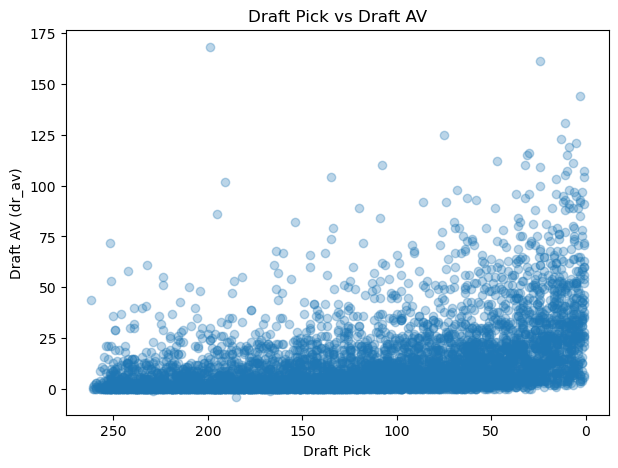

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(merged["pick"], merged["dr_av"], alpha=0.3)

plt.xlabel("Draft Pick")
plt.ylabel("Draft AV (dr_av)")
plt.title("Draft Pick vs Draft AV")

plt.gca().invert_xaxis()

plt.show()

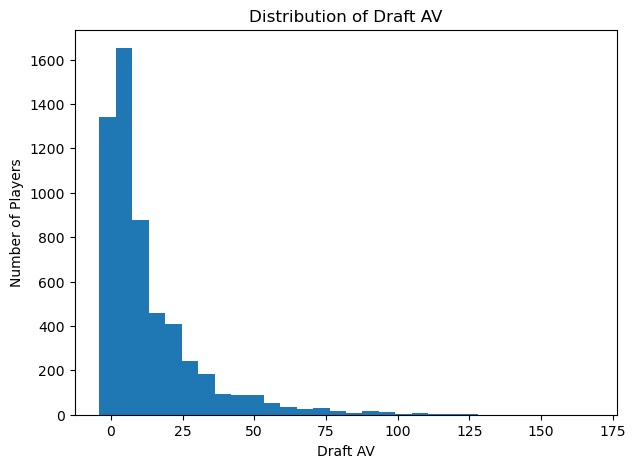

In [73]:
plt.figure(figsize=(7,5))

plt.hist(merged["dr_av"], bins=30)

plt.xlabel("Draft AV")
plt.ylabel("Number of Players")
plt.title("Distribution of Draft AV")

plt.show()

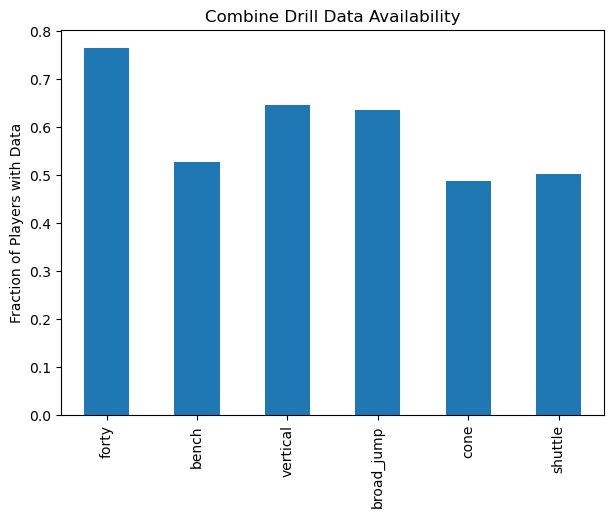

In [74]:
combine_cols = ["forty","bench","vertical","broad_jump","cone","shuttle"]

coverage = merged[combine_cols].notna().mean()

coverage.plot(kind="bar", figsize=(7,5))

plt.ylabel("Fraction of Players with Data")
plt.title("Combine Drill Data Availability")

plt.show()

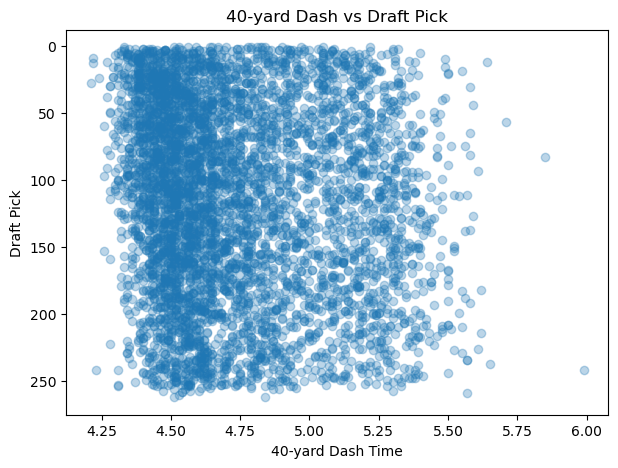

In [75]:
plt.figure(figsize=(7,5))

plt.scatter(merged["forty"], merged["pick"], alpha=0.3)

plt.xlabel("40-yard Dash Time")
plt.ylabel("Draft Pick")
plt.title("40-yard Dash vs Draft Pick")

plt.gca().invert_yaxis()

plt.show()

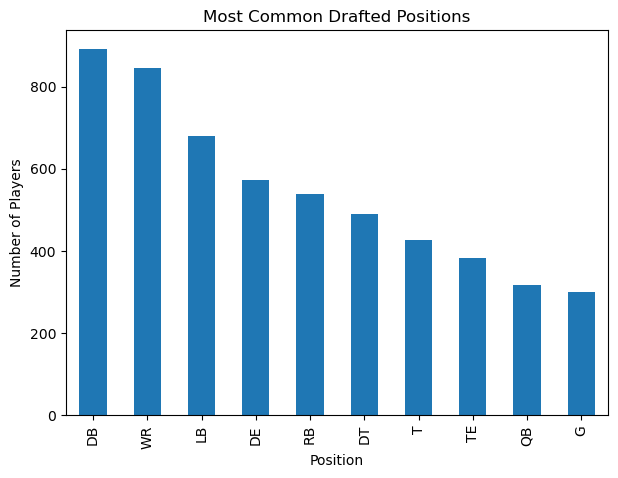

In [76]:
merged["position"].value_counts().head(10).plot(
    kind="bar",
    figsize=(7,5)
)

plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.title("Most Common Drafted Positions")

plt.show()

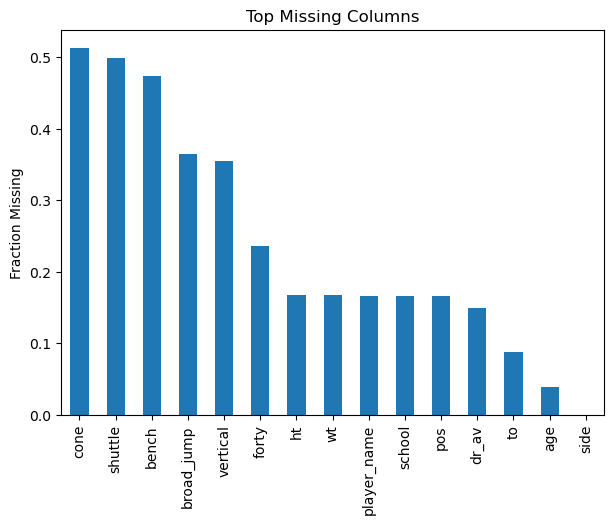

In [77]:
missing = merged.isna().mean().sort_values(ascending=False)

missing.head(15).plot(kind="bar", figsize=(7,5))

plt.ylabel("Fraction Missing")
plt.title("Top Missing Columns")

plt.show()

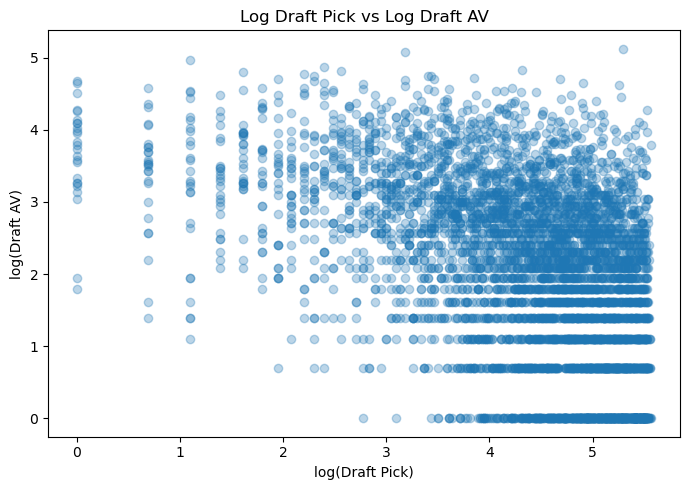

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# remove zero values to avoid log issues
df = merged[merged["dr_av"] > 0]

plt.figure(figsize=(7,5))

plt.scatter(
    np.log(df["pick"]),
    np.log(df["dr_av"]),
    alpha=0.3
)

plt.xlabel("log(Draft Pick)")
plt.ylabel("log(Draft AV)")
plt.title("Log Draft Pick vs Log Draft AV")

plt.tight_layout()
plt.show()

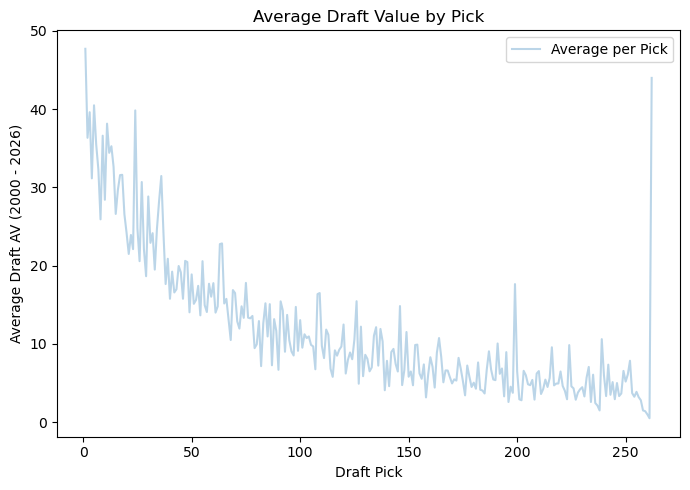

In [87]:
avg = merged.groupby("pick")["dr_av"].mean()

# rolling_avg = avg.rolling(window=10).mean()

plt.figure(figsize=(7,5))

plt.plot(avg.index, avg, alpha=0.3, label="Average per Pick")
# plt.plot(rolling_avg.index, rolling_avg, linewidth=3, label="10-Pick Rolling Avg")

plt.xlabel("Draft Pick")
plt.ylabel("Average Draft AV (2000 - 2026)")
plt.title("Average Draft Value by Pick")

plt.gca()

plt.legend()

plt.tight_layout()
plt.show()

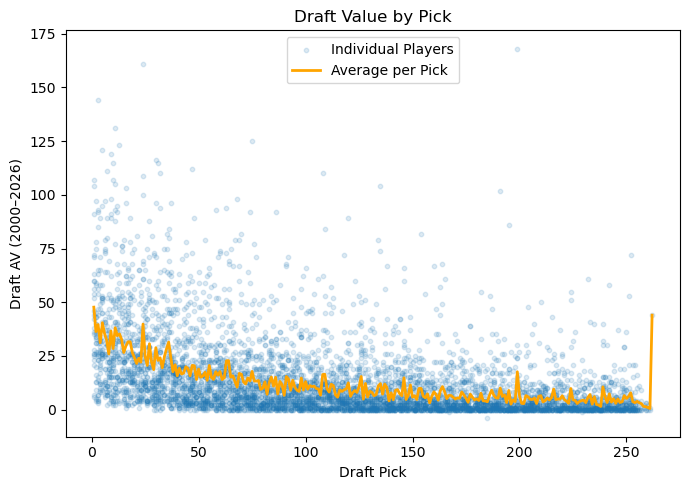

In [ ]:
import matplotlib.pyplot as plt

# compute average
avg = merged.groupby("pick")["dr_av"].mean()


plt.figure(figsize=(7,5))

# all individual players
plt.scatter(
    merged["pick"],
    merged["dr_av"],
    alpha=0.15,
    s=10,
    label="Individual Players"
)

# average line
plt.plot(
    avg.index,
    avg,
    color="orange",
    linewidth=2,
    label="Average per Pick"
)


plt.xlabel("Draft Pick")
plt.ylabel("Draft AV (2000–2026)")
plt.title("Draft Value by Pick")

# earlier picks left
plt.gca()

plt.legend()

plt.tight_layout()
plt.show()

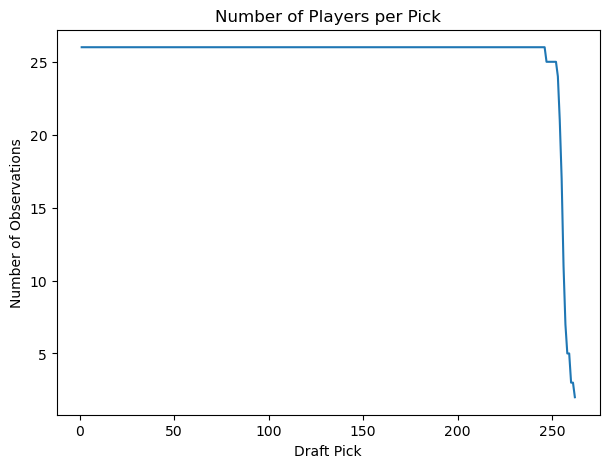

In [80]:
counts = merged.groupby("pick").size()

plt.figure(figsize=(7,5))
plt.plot(counts.index, counts.values)

plt.xlabel("Draft Pick")
plt.ylabel("Number of Observations")
plt.title("Number of Players per Pick")

plt.show()

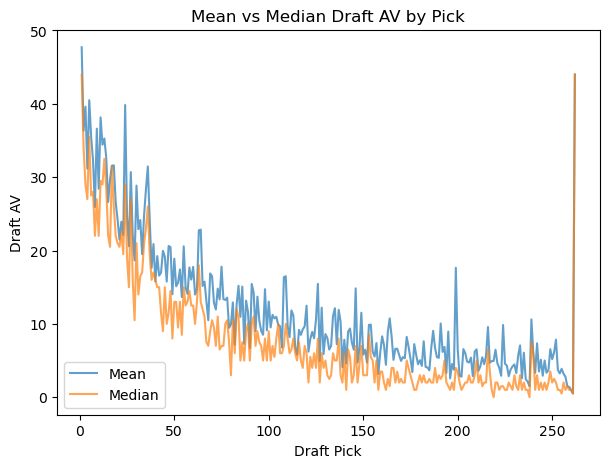

In [85]:
avg = merged.groupby("pick")["dr_av"].mean()
median = merged.groupby("pick")["dr_av"].median()

plt.figure(figsize=(7,5))

plt.plot(avg.index, avg, label="Mean", alpha=0.7)
plt.plot(median.index, median, label="Median", alpha=0.7)

plt.xlabel("Draft Pick")
plt.ylabel("Draft AV")
plt.title("Mean vs Median Draft AV by Pick")

plt.gca()
plt.legend()

plt.show()

In [84]:
merged[merged["pick"] > 255][["season","pick","player_name","dr_av"]].sort_values("dr_av", ascending=False)

,season,pick,player_name,dr_av
5877,2022,262,Brock Purdy,44.0
2554,2009,256,NaN,11.0
756,2002,257,Rock Cartwright,9.0
6134,2023,257,Alex Forsyth,4.0
5871,2022,256,Jesse Luketa,3.0
6136,2023,259,NaN,3.0
5874,2022,259,NaN,3.0
759,2002,260,Dominique Stevenson,2.0
4846,2018,256,Trey Quinn,2.0
5873,2022,258,NaN,2.0


In [91]:
merged["dr_av"].describe()

count    5651.000000
mean       12.983012
std        17.453211
min        -4.000000
25%         2.000000
50%         7.000000
75%        17.000000
max       168.000000
Name: dr_av, dtype: float64

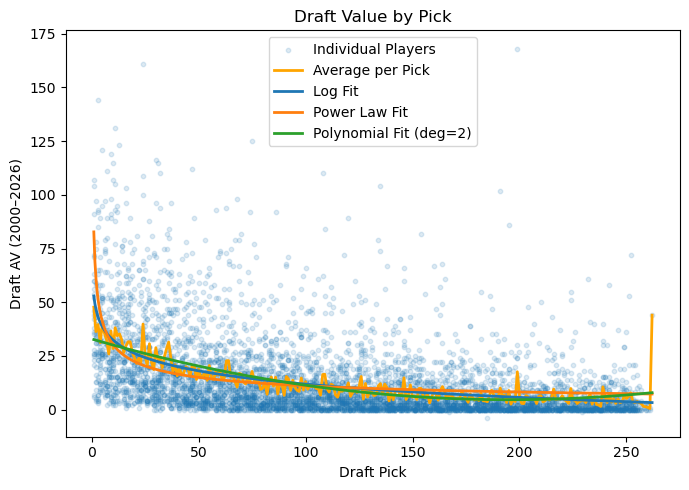

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# compute average
avg = merged.groupby("pick")["dr_av"].mean()

x = avg.index.values
y = avg.values

# -------------------
# models
# -------------------

def log_model(p, a, b):
    return a - b*np.log(p)

def power_model(p, a, b):
    return a * p**(-b)

# fit models
params_log, _ = curve_fit(log_model, x+1, y)
params_power, _ = curve_fit(power_model, x+1, y)

# polynomial fit
poly = np.polyfit(x, y, 2)
poly_fn = np.poly1d(poly)

# smooth x range
x_line = np.linspace(1, 262, 500)

# -------------------
# plot
# -------------------

plt.figure(figsize=(7,5))

# individual players
plt.scatter(
    merged["pick"],
    merged["dr_av"],
    alpha=0.15,
    s=10,
    label="Individual Players"
)

# average
plt.plot(
    x,
    y,
    color="orange",
    linewidth=2,
    label="Average per Pick"
)

# fitted lines
plt.plot(
    x_line,
    log_model(x_line, *params_log),
    linewidth=2,
    label="Log Fit"
)

plt.plot(
    x_line,
    power_model(x_line, *params_power),
    linewidth=2,
    label="Power Law Fit"
)

plt.plot(
    x_line,
    poly_fn(x_line),
    linewidth=2,
    label="Polynomial Fit (deg=2)"
)

plt.xlabel("Draft Pick")
plt.ylabel("Draft AV (2000–2026)")
plt.title("Draft Value by Pick")

plt.legend()

plt.tight_layout()
plt.show()

Model accuracy (R²)
Log model:       0.8097
Power law:       0.7186
Polynomial deg2: 0.7911

Best model: Log Fit


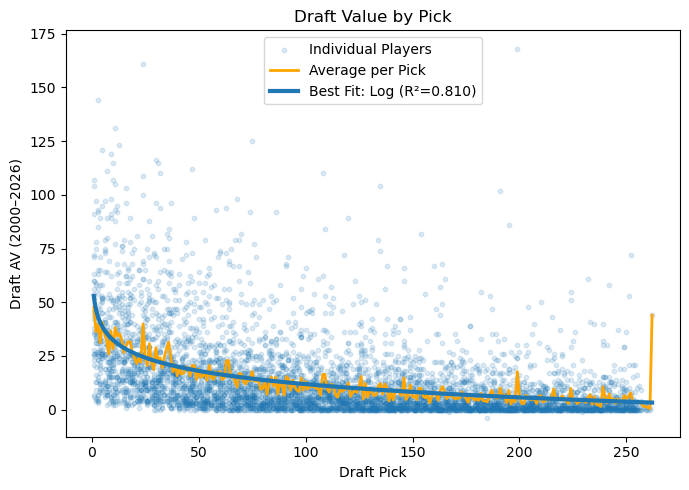

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# compute average
avg = merged.groupby("pick")["dr_av"].mean()

x = avg.index.values
y = avg.values

# -------------------
# models
# -------------------

def log_model(p, a, b):
    return a - b*np.log(p)

def power_model(p, a, b):
    return a * p**(-b)

# fit models
params_log, _ = curve_fit(log_model, x+1, y)
params_power, _ = curve_fit(power_model, x+1, y)

poly = np.polyfit(x, y, 2)
poly_fn = np.poly1d(poly)

# predictions
y_log = log_model(x+1, *params_log)
y_power = power_model(x+1, *params_power)
y_poly = poly_fn(x)

# -------------------
# accuracy (R²)
# -------------------

r2_log = r2_score(y, y_log)
r2_power = r2_score(y, y_power)
r2_poly = r2_score(y, y_poly)

print("Model accuracy (R²)")
print(f"Log model:       {r2_log:.4f}")
print(f"Power law:       {r2_power:.4f}")
print(f"Polynomial deg2: {r2_poly:.4f}")

# choose best
models = {
    "Log Fit": (y_log, r2_log),
    "Power Law Fit": (y_power, r2_power),
    "Polynomial Fit": (y_poly, r2_poly)
}

best_model = max(models, key=lambda k: models[k][1])
print(f"\nBest model: {best_model}")

# -------------------
# plotting
# -------------------

x_line = np.linspace(1, 262, 500)

plt.figure(figsize=(7,5))

plt.scatter(
    merged["pick"],
    merged["dr_av"],
    alpha=0.15,
    s=10,
    label="Individual Players"
)

plt.plot(x, y, color="orange", linewidth=2, label="Average per Pick")

# plot best fit only
if best_model == "Log Fit":
    plt.plot(x_line, log_model(x_line, *params_log),
             linewidth=3, label=f"Best Fit: Log (R²={r2_log:.3f})")

elif best_model == "Power Law Fit":
    plt.plot(x_line, power_model(x_line, *params_power),
             linewidth=3, label=f"Best Fit: Power Law (R²={r2_power:.3f})")

else:
    plt.plot(x_line, poly_fn(x_line),
             linewidth=3, label=f"Best Fit: Polynomial (R²={r2_poly:.3f})")

plt.xlabel("Draft Pick")
plt.ylabel("Draft AV (2000–2026)")
plt.title("Draft Value by Pick")

plt.legend()
plt.tight_layout()
plt.show()

Model metrics

Log model:
  R²   = 0.810
  RMSE = 3.974

Power law:
  R²   = 0.719
  RMSE = 4.832

Polynomial (deg2):
  R²   = 0.791
  RMSE = 4.164

Best model: Log Fit


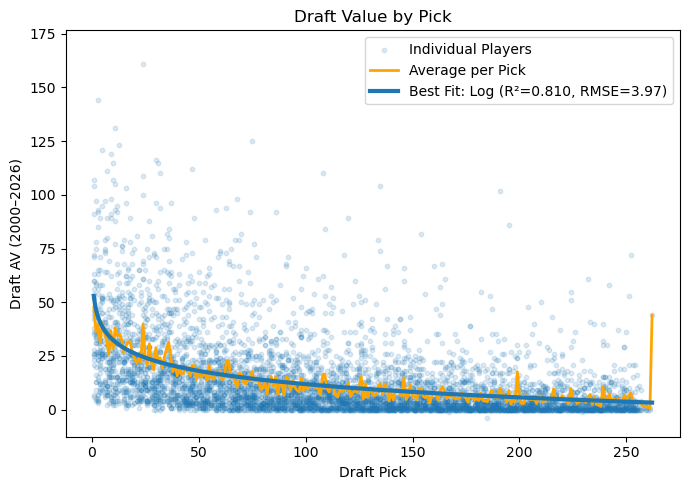

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

# compute average
avg = merged.groupby("pick")["dr_av"].mean()

x = avg.index.values
y = avg.values

# -------------------
# models
# -------------------

def log_model(p, a, b):
    return a - b*np.log(p)

def power_model(p, a, b):
    return a * p**(-b)

# fit models
params_log, _ = curve_fit(log_model, x+1, y)
params_power, _ = curve_fit(power_model, x+1, y)

poly = np.polyfit(x, y, 2)
poly_fn = np.poly1d(poly)

# predictions
y_log = log_model(x+1, *params_log)
y_power = power_model(x+1, *params_power)
y_poly = poly_fn(x)

# -------------------
# metrics
# -------------------

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

r2_log = r2_score(y, y_log)
r2_power = r2_score(y, y_power)
r2_poly = r2_score(y, y_poly)

rmse_log = rmse(y, y_log)
rmse_power = rmse(y, y_power)
rmse_poly = rmse(y, y_poly)

print("Model metrics\n")

print(f"Log model:")
print(f"  R²   = {r2_log:.3f}")
print(f"  RMSE = {rmse_log:.3f}")

print(f"\nPower law:")
print(f"  R²   = {r2_power:.3f}")
print(f"  RMSE = {rmse_power:.3f}")

print(f"\nPolynomial (deg2):")
print(f"  R²   = {r2_poly:.3f}")
print(f"  RMSE = {rmse_poly:.3f}")

# choose best model by R²
models = {
    "Log Fit": (r2_log, rmse_log),
    "Power Law Fit": (r2_power, rmse_power),
    "Polynomial Fit": (r2_poly, rmse_poly)
}

best_model = max(models, key=lambda k: models[k][0])
print(f"\nBest model: {best_model}")

# -------------------
# plotting
# -------------------

x_line = np.linspace(1, 262, 500)

plt.figure(figsize=(7,5))

plt.scatter(
    merged["pick"],
    merged["dr_av"],
    alpha=0.15,
    s=10,
    label="Individual Players"
)

plt.plot(x, y, color="orange", linewidth=2, label="Average per Pick")

if best_model == "Log Fit":
    plt.plot(x_line, log_model(x_line, *params_log),
             linewidth=3,
             label=f"Best Fit: Log (R²={r2_log:.3f}, RMSE={rmse_log:.2f})")

elif best_model == "Power Law Fit":
    plt.plot(x_line, power_model(x_line, *params_power),
             linewidth=3,
             label=f"Best Fit: Power (R²={r2_power:.3f}, RMSE={rmse_power:.2f})")

else:
    plt.plot(x_line, poly_fn(x_line),
             linewidth=3,
             label=f"Best Fit: Poly (R²={r2_poly:.3f}, RMSE={rmse_poly:.2f})")

plt.xlabel("Draft Pick")
plt.ylabel("Draft AV (2000–2026)")
plt.title("Draft Value by Pick")

plt.legend()
plt.tight_layout()
plt.show()

In [95]:
corr_by_year = (
    merged
    .groupby("season")
    .apply(lambda df: df["pick"].corr(df["dr_av"]))
)

print(corr_by_year)

season
2000   -0.316319
2001   -0.476311
2002   -0.427597
2003   -0.464550
2004   -0.444972
2005   -0.451153
2006   -0.366744
2007   -0.422831
2008   -0.421637
2009   -0.464504
2010   -0.498033
2011   -0.466022
2012   -0.462593
2013   -0.457238
2014   -0.446869
2015   -0.509450
2016   -0.432030
2017   -0.441566
2018   -0.491201
2019   -0.556185
2020   -0.520762
2021   -0.534830
2022   -0.484062
2023   -0.567406
2024   -0.600487
2025   -0.550884
dtype: float64


In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

r2_by_year = {}

for year, df in merged.groupby("season"):
    
    # remove rows with missing AV
    df = df.dropna(subset=["dr_av"])
    
    X = df[["pick"]]
    y = df["dr_av"]
    
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    
    r2_by_year[year] = r2_score(y, preds)

import pandas as pd
r2_series = pd.Series(r2_by_year)

print(r2_series)

2000    0.100058
2001    0.226873
2002    0.182839
2003    0.215807
2004    0.198000
2005    0.203539
2006    0.134501
2007    0.178786
2008    0.177777
2009    0.215764
2010    0.248037
2011    0.217176
2012    0.213992
2013    0.209067
2014    0.199692
2015    0.259539
2016    0.186650
2017    0.194980
2018    0.241278
2019    0.309342
2020    0.271193
2021    0.286043
2022    0.234316
2023    0.321949
2024    0.360584
2025    0.303473
dtype: float64


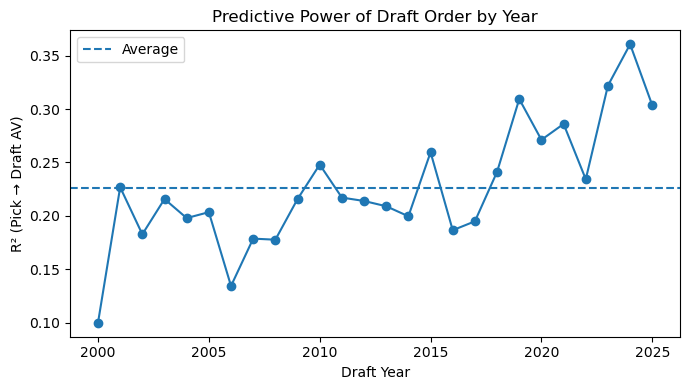

In [98]:
plt.figure(figsize=(7,4))

plt.plot(r2_series.index, r2_series.values, marker="o")

plt.axhline(r2_series.mean(), linestyle="--", label="Average")

plt.xlabel("Draft Year")
plt.ylabel("R² (Pick → Draft AV)")
plt.title("Predictive Power of Draft Order by Year")

plt.legend()
plt.tight_layout()
plt.show()

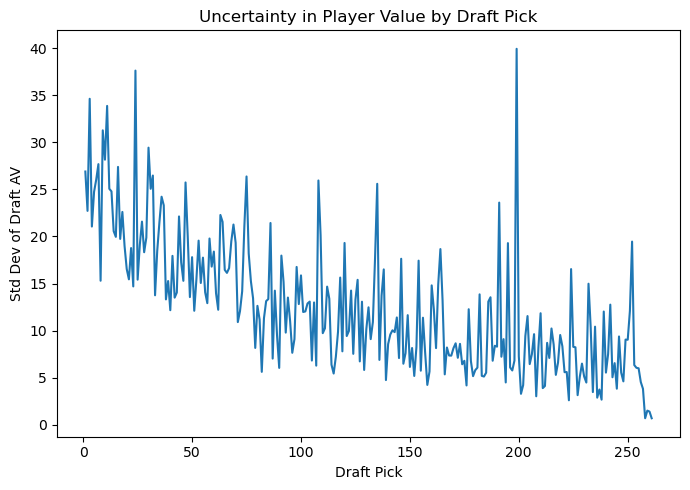

In [99]:
var_by_pick = merged.groupby("pick")["dr_av"].std()

plt.figure(figsize=(7,5))

plt.plot(var_by_pick.index, var_by_pick.values)

plt.xlabel("Draft Pick")
plt.ylabel("Std Dev of Draft AV")
plt.title("Uncertainty in Player Value by Draft Pick")

plt.tight_layout()
plt.show()

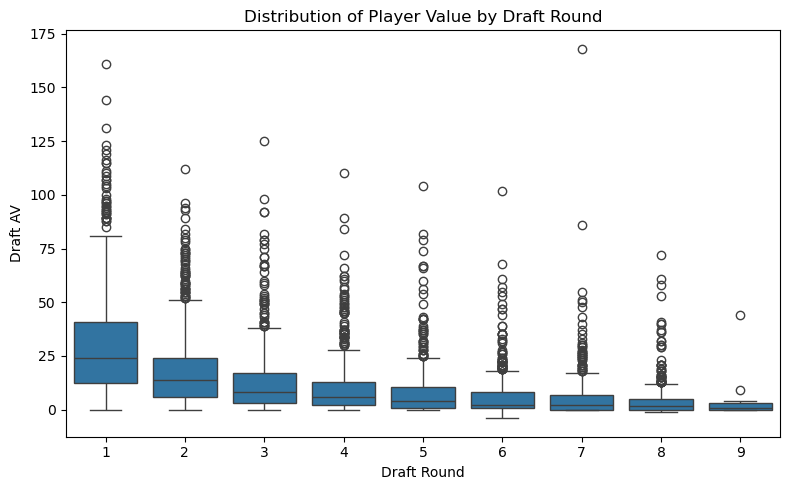

In [101]:
merged["round"] = ((merged["pick"] - 1) // 32) + 1

import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(data=merged, x="round", y="dr_av")

plt.xlabel("Draft Round")
plt.ylabel("Draft AV")
plt.title("Distribution of Player Value by Draft Round")

plt.tight_layout()
plt.show()

In [102]:
first_round = merged[merged["pick"] <= 32]["dr_av"].median()
late_round = merged[merged["pick"] > 100]

(late_round["dr_av"] > first_round).mean()

np.float64(0.04426310583580613)

In [103]:
merged.to_csv(RAW_DIR / "combine_vs_av_2000_2026.csv", index=False)